## Import data

In [18]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from enum import Enum
from typing import Literal

In [3]:
OUTCOMES = ["CR", "NegR", "NR", "PR"]
class StatValue(Enum):
    LOESS = "LOESS"
    QUARTILE_1 = "QUARTILE_1"
    QUARTILE_2 = "QUARTILE_2"
    QUARTILE_3 = "QUARTILE_3"
    MEDIAN_AND_GEOM_MEAN = "MEDIAN_AND_GEOM_MEAN"
    MEAN = "MEAN"
    INDIVIDUAL = "INDIVIDUAL"   # same as Original in paper
    BM_M1_STATUS = "BM_M1_STATUS"
    BM_M2_STATUS = "BM_M2_STATUS"
    BM_M3_STATUS = "BM_M3_STATUS"


# TODO: add demographic info
@dataclass
class GroupInfo:
    ref: int
    num_indiv: int
    stat_value: StatValue

INFO_LOOKUP_BY_OUTCOME_GROUP = {
    "CR": {
        1: GroupInfo(5, 45, StatValue.LOESS),
        2: GroupInfo(3, 14, StatValue.QUARTILE_1),
        3: GroupInfo(3, 14, StatValue.QUARTILE_2),
        4: GroupInfo(3, 14, StatValue.QUARTILE_3),
        5: GroupInfo(6, 59, StatValue.MEDIAN_AND_GEOM_MEAN),
        6: GroupInfo(7, 1, StatValue.INDIVIDUAL),
        7: GroupInfo(8, 8, StatValue.MEAN),
        8: GroupInfo(9, 1, StatValue.INDIVIDUAL),
        9: GroupInfo(10, 4, StatValue.BM_M1_STATUS),
        10: GroupInfo(10, 4, StatValue.BM_M2_STATUS),
        11: GroupInfo(10, 4, StatValue.BM_M3_STATUS),
        12: GroupInfo(11, 1, StatValue.INDIVIDUAL),
        13: GroupInfo(11, 1, StatValue.INDIVIDUAL),
        14: GroupInfo(11, 1, StatValue.INDIVIDUAL),
    },
    "NR": {
        1: GroupInfo(5, 8, StatValue.LOESS),
        2: GroupInfo(3, 6, StatValue.MEAN),
        3: GroupInfo(6, 6, StatValue.MEDIAN_AND_GEOM_MEAN),
        4: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        5: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        6: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        7: GroupInfo(12, 1, StatValue.INDIVIDUAL),
    },
    "PR": {
        1: GroupInfo(5, 14, StatValue.LOESS),
        2: GroupInfo(9, 1, StatValue.INDIVIDUAL),
        3: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        4: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        5: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        6: GroupInfo(12, 1, StatValue.INDIVIDUAL),
        7: GroupInfo(12, 1, StatValue.INDIVIDUAL),
    },
    "NegR": {
        1: GroupInfo(5, 14, StatValue.LOESS),
        2: GroupInfo(7, 1, StatValue.INDIVIDUAL),
        3: GroupInfo(13, 1, StatValue.INDIVIDUAL),
        4: GroupInfo(13, 1, StatValue.INDIVIDUAL),
    },
}

In [4]:
def add_row_info(row: pd.Series):
    row["ref"] = INFO_LOOKUP_BY_OUTCOME_GROUP[row["outcome"]][row["ID"]].ref
    row["num_indiv"] = INFO_LOOKUP_BY_OUTCOME_GROUP[row["outcome"]][row["ID"]].num_indiv
    row["stat_value"] = INFO_LOOKUP_BY_OUTCOME_GROUP[row["outcome"]][
        row["ID"]
    ].stat_value.value
    return row


df: pd.DataFrame
for i, outcome in enumerate(OUTCOMES):
    if i == 0:
        df = pd.read_csv(f"Data_{outcome}.csv")
        df.loc[:, "outcome"] = outcome
    else:
        df_chunk = pd.read_csv(f"Data_{outcome}.csv")
        df_chunk.loc[:, "outcome"] = outcome
        df = pd.concat([df, df_chunk])
df = df.apply(add_row_info, axis="columns")

## Partial summary of data

In [ ]:
outcome_group_to_summary = {
    
}

source_id_to_summary_partial = {
    3: {
        "demographics": 
    }
}

NameError: name 'outcome_group_to_info' is not defined

## Plot data

In [12]:
import matplotlib.pyplot as plt

In [19]:
def count_to_burden(count: float | np.ndarray):
    """
    `count` is the B-ALL cell number divided by 10^9
    """
    return 97.19 * np.array(count) / (1909 + np.array(count))

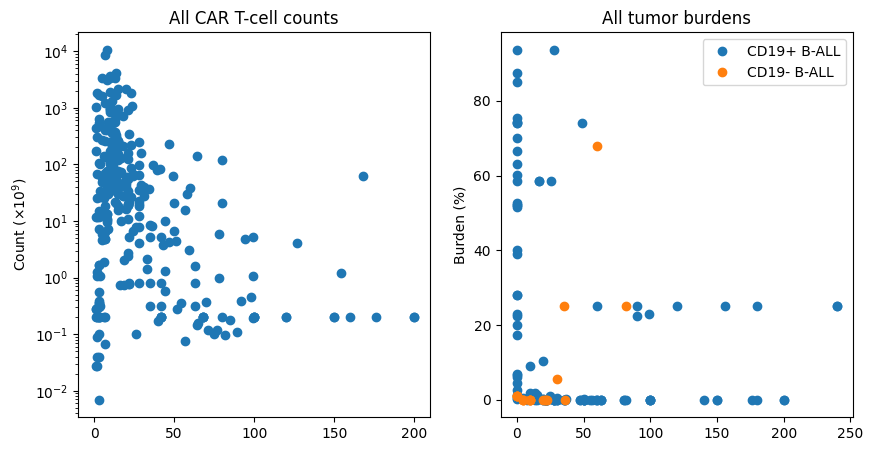

In [46]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

car_t = df[df["y_ID"] == 1]
cd19p_ball = df[df["y_ID"] == 2]
cd19n_ball = df[df["y_ID"] == 3]
axs[0].semilogy(car_t["time"], car_t["y"], "o")
axs[0].set_ylabel("Count ($\\times 10^9$)")
axs[0].set_title("All CAR T-cell counts")
axs[1].plot(cd19p_ball["time"], count_to_burden(cd19p_ball["y"]), "o", label="CD19+ B-ALL")
axs[1].plot(cd19n_ball["time"], count_to_burden(cd19n_ball["y"]), "o", label="CD19- B-ALL")
axs[1].set_ylabel("Burden (%)")
axs[1].legend()
axs[1].set_title("All tumor burdens")

plt.show()

In [36]:
len(df.loc[:, ["ID", "outcome"]].drop_duplicates())

32

In [13]:
data_by_outcome_group = {}

for outcome in INFO_LOOKUP_BY_OUTCOME_GROUP:
    for id in INFO_LOOKUP_BY_OUTCOME_GROUP[outcome]:
        t_cart, n_cart = (
            df[(df["ID"] == id) & (df["outcome"] == outcome) & (df["y_ID"] == 1)]
            .loc[:, ["time", "y"]]
            .to_numpy()
            .T
        )
        t_ball_p, n_ball_p = (
            df[(df["ID"] == id) & (df["outcome"] == outcome) & (df["y_ID"] == 2)]
            .loc[:, ["time", "y"]]
            .to_numpy()
            .T
        )
        t_ball_n, n_ball_n = (
            df[(df["ID"] == id) & (df["outcome"] == outcome) & (df["y_ID"] == 3)]
            .loc[:, ["time", "y"]]
            .to_numpy()
            .T
        )
        group_info = INFO_LOOKUP_BY_OUTCOME_GROUP[outcome][id]

        group_data = {
            "is_indiv": group_info.num_indiv == 1,
            "ref": group_info.ref,
            "t_cart": t_cart,
            "n_cart": n_cart,
            "t_ball_p": t_ball_p,
            "n_ball_p": n_ball_p,
            "t_ball_n": t_ball_n,
            "n_ball_n": n_ball_n,
        }
        data_by_outcome_group[(outcome, id)] = group_data

In [39]:
# TODO: sort by indiv/agg


def plot_indiv_by_type(y_type: Literal["cart", "ball", "ball-burden"]):
    cmap = plt.get_cmap("tab10")  # perfect: we have 10 sources
    fig, axs = plt.subplots(nrows=4, ncols=8, figsize=(20, 10))
    fig.suptitle(
        {
            "cart": "CAR T-cell count",
            "ball": "B-ALL cell count",
            "ball-burden": "Tumor burden"
        }[y_type]
    )
    axs = axs.flatten()
    for i, outcome_id in enumerate(data_by_outcome_group):
        group_data = data_by_outcome_group[outcome_id]
        color = cmap(list(df["ref"].unique()).index(group_data["ref"]))
        if y_type == "cart":
            axs[i].semilogy(
                group_data[f"t_cart"],
                group_data[f"n_cart"],
                "o",
                markersize=3,
                color=color,
            )
            axs[i].set_ylabel("Count ($\\times 10^9$)")
        elif y_type == "ball":
            axs[i].semilogy(
                group_data[f"t_ball_p"],
                group_data[f"n_ball_p"],
                "o",
                markersize=3,
                label="CD19+",
                color=color,
            )
            if len(group_data[f"t_ball_n"]) > 0:
                axs[i].semilogy(
                    group_data[f"t_ball_n"],
                    group_data[f"n_ball_n"],
                    "x",
                    markersize=5,
                    label="CD19-",
                    color=color,
                )
            axs[i].set_ylabel("Count ($\\times 10^9$)")
            axs[i].legend()
        elif y_type == "ball-burden":
            axs[i].plot(
                group_data[f"t_ball_p"],
                count_to_burden(group_data[f"n_ball_p"]),
                "o",
                markersize=3,
                label="CD19+",
                color=color,
            )
            if len(group_data[f"t_ball_n"]) > 0:
                axs[i].plot(
                    group_data[f"t_ball_n"],
                    count_to_burden(group_data[f"n_ball_n"]),
                    "x",
                    markersize=5,
                    label="CD19-",
                    color=color,
                )
            axs[i].set_ylabel("Burden (%)")
            axs[i].legend()
        else:
            raise ValueError(f"Invalid y_type {y_type}")
        axs[i].set_xlabel("$t$ (days)")
        axs[i].set_title(
            f"[{group_data['ref']}] id {outcome_id[1]}, {outcome_id[0]} ({r'$\mathbf{IND}$' if group_data['is_indiv'] else 'agg'})"
        )
    plt.tight_layout()
    plt.show()

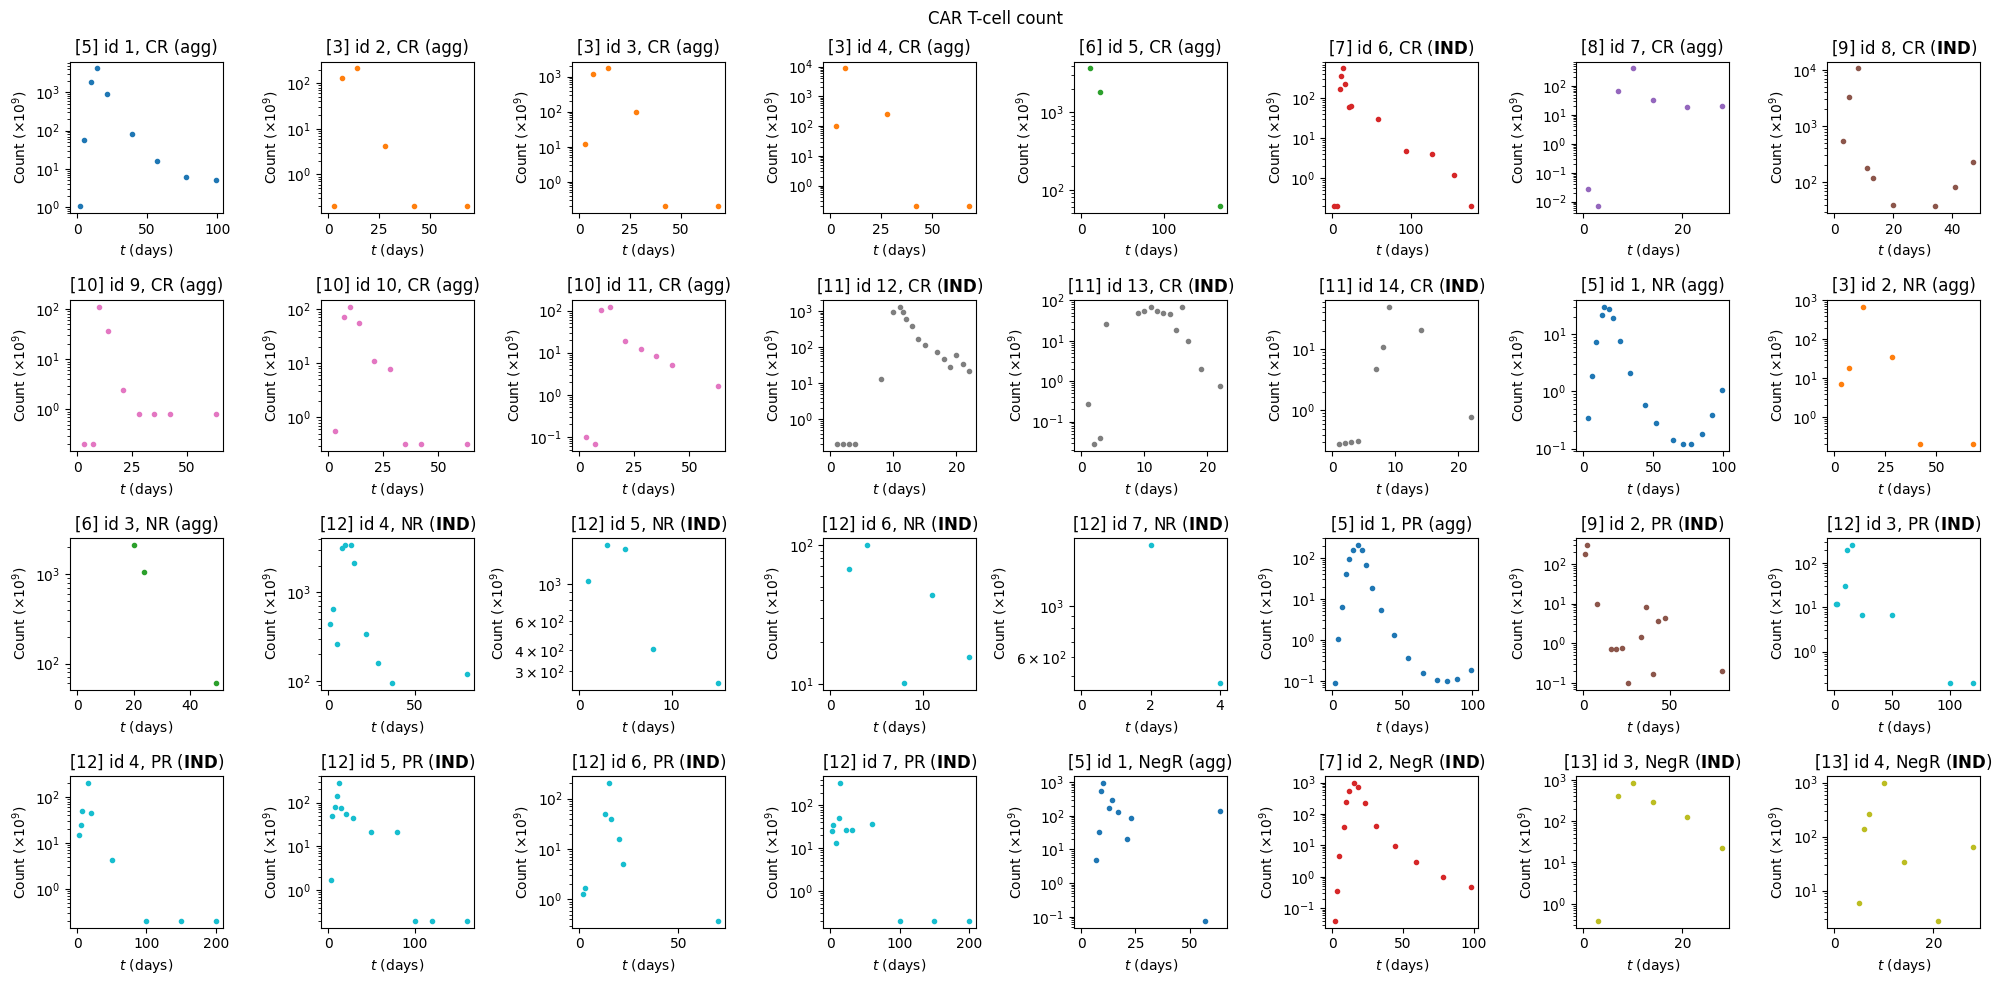

In [40]:
plot_indiv_by_type("cart")

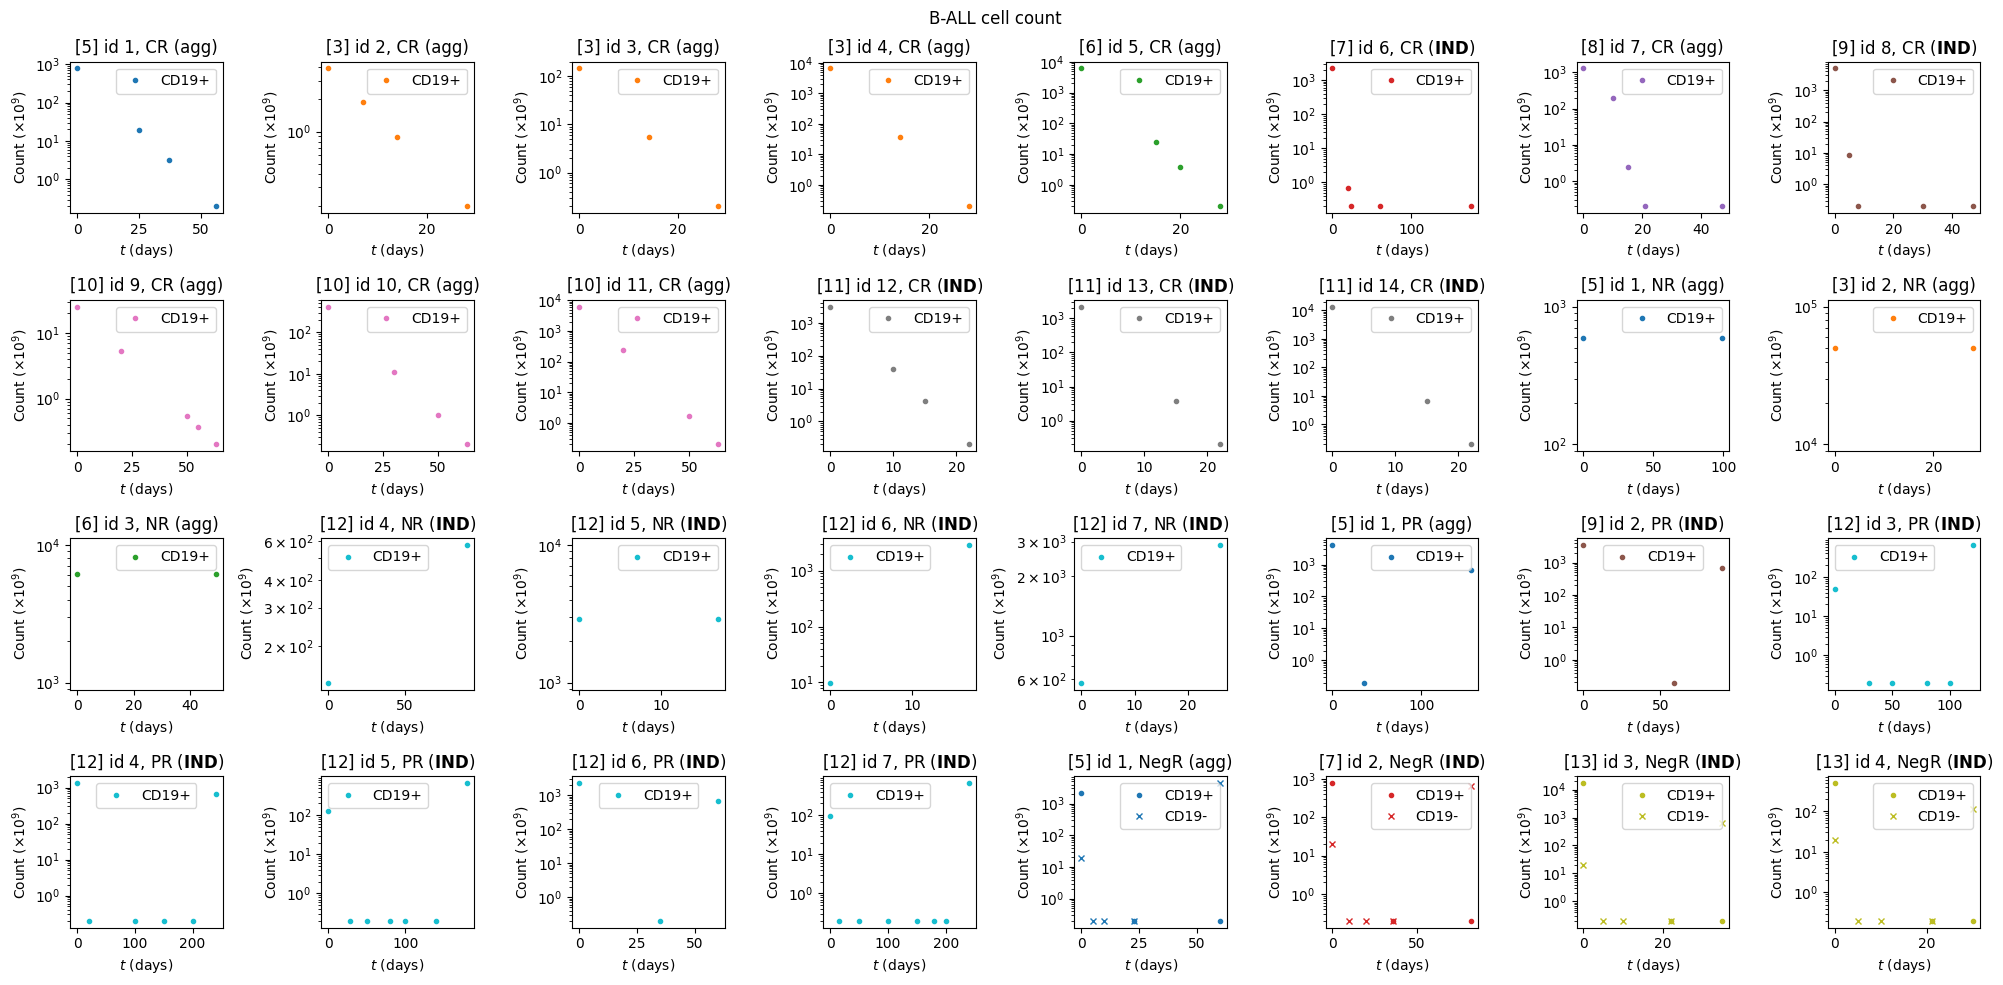

In [41]:
plot_indiv_by_type("ball")

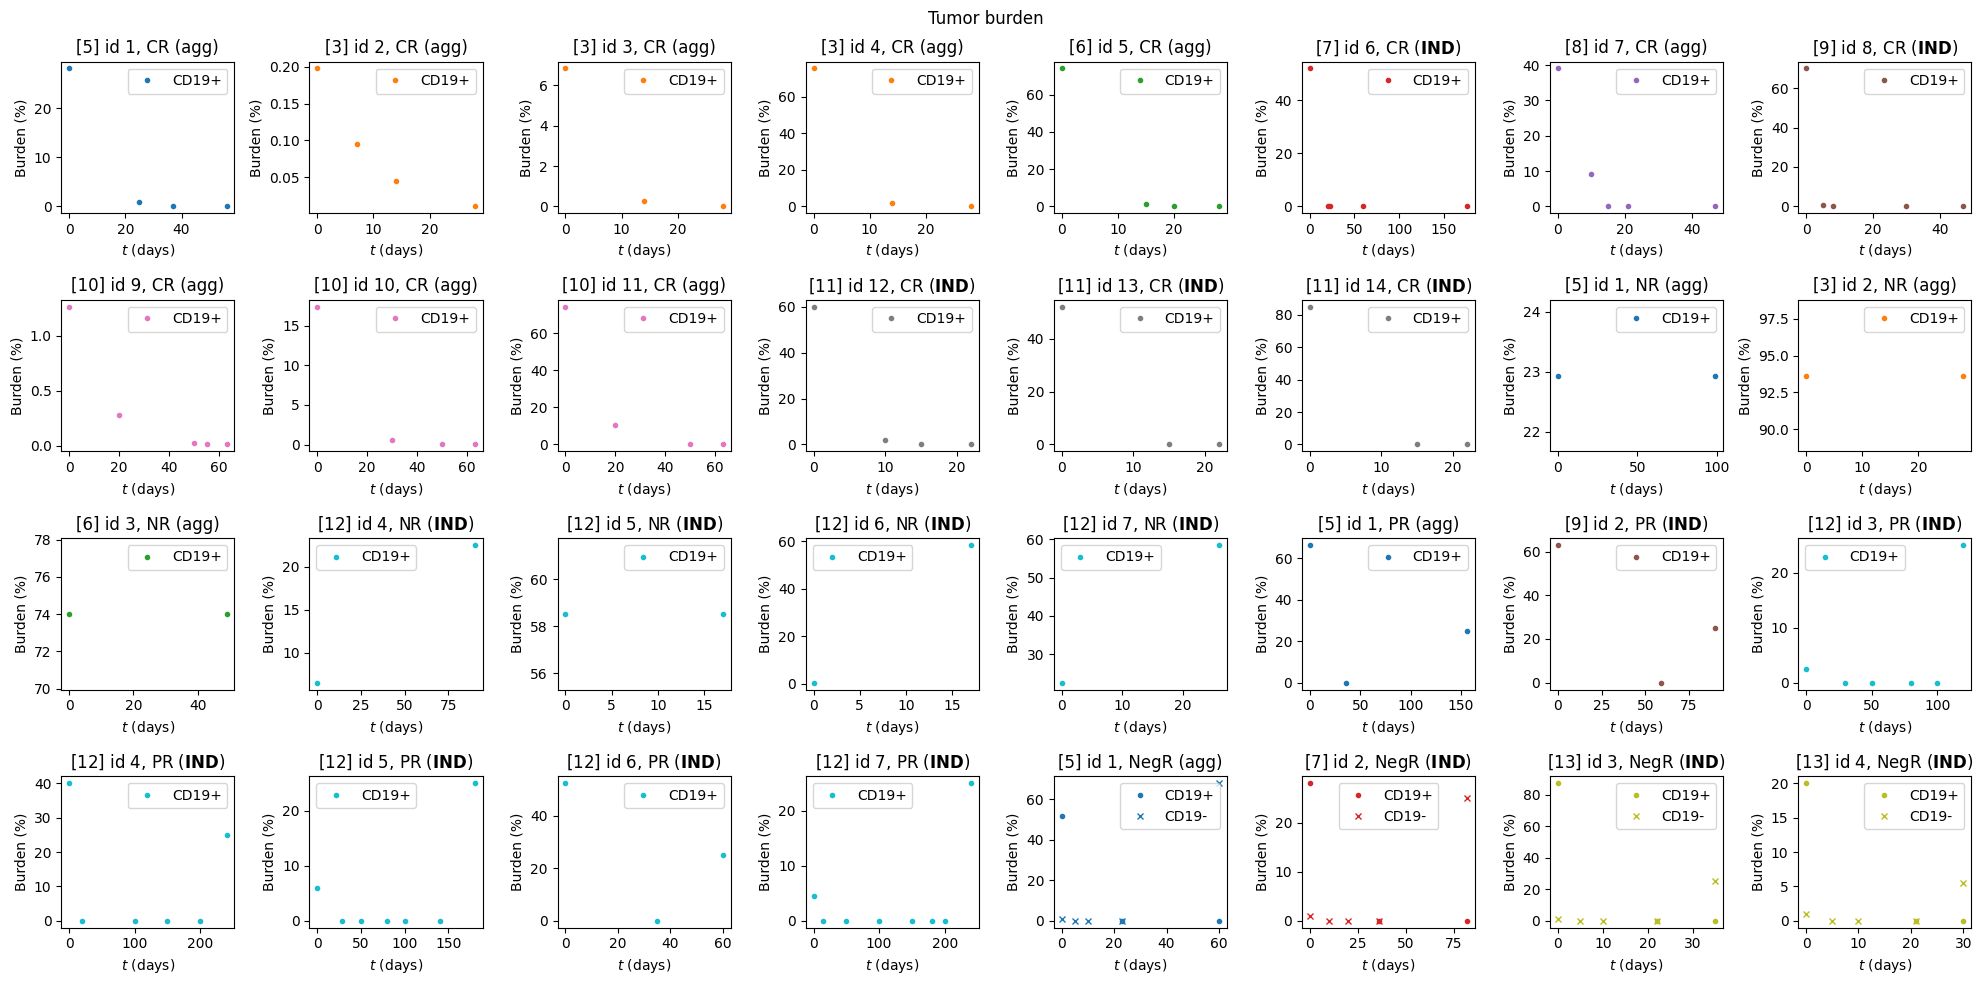

In [42]:
plot_indiv_by_type("ball-burden")